[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Biswajit1999/daily-astro-notebooks/blob/master/exoplanet-archive/2026-07-30-transit-depth-vs-radius/notebook.ipynb)

# Does a bigger planet really block more starlight? Transit depth vs. radius

**Learning goals** -- after this notebook you will be able to:
- Pull the current confirmed-planet composite table from the NASA Exoplanet Archive via a live TAP query and apply real quality cuts.
- Compute the *geometric* transit depth prediction, delta F/F = (Rp/Rstar)^2, from real archive radii and compare it to the archive's own reported/derived transit depth.
- Quantify how well the geometric model explains the reported depths using residual statistics (RMS, median absolute deviation) rather than eyeballing a scatter plot.
- Split a planet sample into physically meaningful radius bins (sub-Earth through Jupiter-sized) and show, with real per-bin counts, how the depth-radius scaling differs across the bins.

**Background.** A transit happens when a planet crosses in front of its star as seen from Earth, blocking a small fraction of the starlight; that fractional dip is the transit depth. To first order, geometry alone predicts depth = (Rp/Rstar)^2, where Rp is the planet radius and Rstar is the stellar radius -- a bigger planet, or a smaller star, blocks proportionally more light. Real reported/derived depths deviate from this simple geometric prediction because of limb darkening, impact parameter, non-grazing vs. grazing geometry, and because the archive's `pl_trandep` column is sometimes derived independently rather than from the same fit as `pl_rade`/`pl_radj`. This notebook checks, with real numbers, how good the simple geometric approximation actually is.

## 1. Pull the real confirmed-planet table (NASA Exoplanet Archive, `pscomppars`)

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
import pyvo as vo

svc = vo.dal.TAPService('https://exoplanetarchive.ipac.caltech.edu/TAP')
query = '''
SELECT pl_name, pl_rade, pl_radj, pl_trandep, st_rad, discoverymethod
FROM pscomppars
WHERE tran_flag = 1
'''
tab = svc.search(query).to_table()
raw = tab.to_pandas()
print(f"Raw TAP query returned {len(raw)} transiting-planet rows")
raw.head()

Raw TAP query returned 4716 transiting-planet rows


,pl_name,pl_rade,pl_radj,pl_trandep,st_rad,discoverymethod
0,Kepler-1808 b,3.025113,0.269883,0.06151,0.892,Transit
1,Kepler-418 b,13.450000,1.200000,0.82441,1.090,Transit
2,Kepler-249 d,1.570000,0.140000,0.07561,0.482,Transit
3,Kepler-1408 b,0.890000,0.079400,0.00451,1.350,Transit
4,Kepler-500 b,2.580000,0.230172,0.06521,1.030,Transit


## 2. Real quality filtering

We need a finite planet radius, a finite host-star radius, and a finite reported transit depth. Report exactly how many rows are dropped by each cut.

In [2]:
n0 = len(raw)
df = raw.drop_duplicates('pl_name').copy()
n1 = len(df)
df = df.dropna(subset=['pl_rade', 'st_rad', 'pl_trandep'])
n2 = len(df)
# sanity bounds: keep physically reasonable radii and positive depths
df = df[(df.pl_rade > 0) & (df.pl_rade < 30) & (df.st_rad > 0) & (df.st_rad < 10) & (df.pl_trandep > 0)]
n3 = len(df)

print(f"Start (raw TAP rows):                     {n0}")
print(f"After de-duplicating planet names:         {n1}  (dropped {n0-n1})")
print(f"After requiring finite Rp, Rstar, depth:    {n2}  (dropped {n1-n2})")
print(f"After physical-range sanity cuts:           {n3}  (dropped {n2-n3})")
print(f"\nFinal clean sample: {n3} planets")

Start (raw TAP rows):                     4716
After de-duplicating planet names:         4716  (dropped 0)
After requiring finite Rp, Rstar, depth:    4499  (dropped 217)
After physical-range sanity cuts:           4498  (dropped 1)

Final clean sample: 4498 planets


## 3. Geometric depth model vs. the archive's reported depth

The archive's `pl_trandep` is reported in percent. The geometric prediction is delta F/F = (Rp/Rstar)^2, converted to percent using the Earth-radius-to-solar-radius ratio (1 Earth radius = 0.0091577 solar radii).

In [3]:
R_EARTH_IN_RSUN = 0.0091577
df['depth_geom_pct'] = 100.0 * (df.pl_rade * R_EARTH_IN_RSUN / df.st_rad) ** 2
df['depth_reported_pct'] = df.pl_trandep

resid_dex = np.log10(df.depth_reported_pct) - np.log10(df.depth_geom_pct)
rms_dex = np.sqrt(np.mean(resid_dex**2))
mad_dex = stats.median_abs_deviation(resid_dex, scale='normal')
print(f"log10(reported/geometric) residual: RMS = {rms_dex:.3f} dex, robust MAD = {mad_dex:.3f} dex")
print(f"Median ratio reported/geometric = {np.median(df.depth_reported_pct/df.depth_geom_pct):.3f}")

log10(reported/geometric) residual: RMS = 0.135 dex, robust MAD = 0.059 dex
Median ratio reported/geometric = 1.096


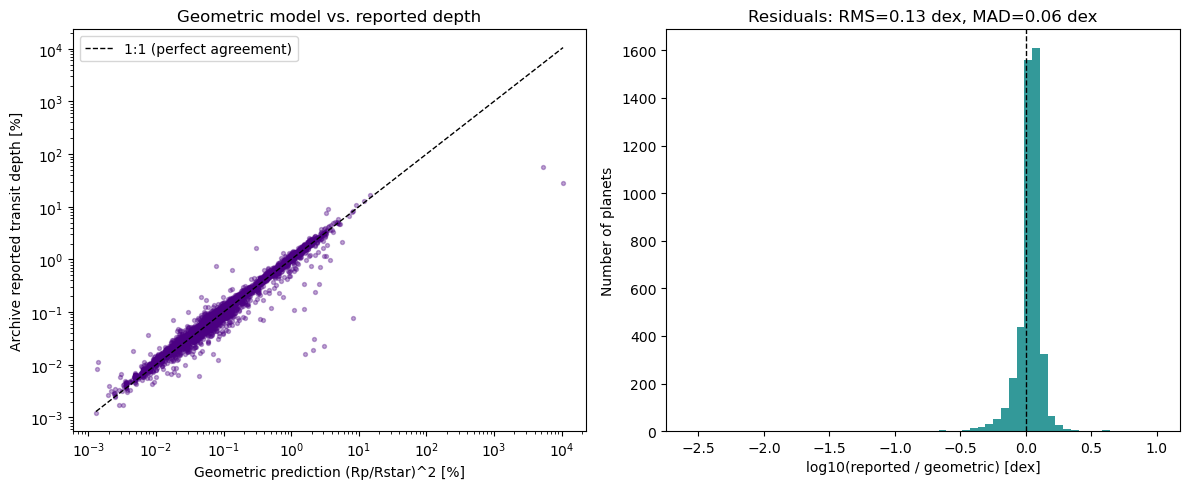

In [4]:
fig, ax = plt.subplots(1, 2, figsize=(12, 5))

ax[0].scatter(df.depth_geom_pct, df.depth_reported_pct, s=8, alpha=0.35, color='indigo')
lims = [df.depth_geom_pct.min(), df.depth_geom_pct.max()]
ax[0].plot(lims, lims, 'k--', lw=1, label='1:1 (perfect agreement)')
ax[0].set_xscale('log'); ax[0].set_yscale('log')
ax[0].set_xlabel('Geometric prediction (Rp/Rstar)^2 [%]')
ax[0].set_ylabel('Archive reported transit depth [%]')
ax[0].set_title('Geometric model vs. reported depth')
ax[0].legend()

ax[1].hist(resid_dex, bins=60, color='teal', alpha=0.8)
ax[1].axvline(0, color='k', ls='--', lw=1)
ax[1].set_xlabel('log10(reported / geometric) [dex]')
ax[1].set_ylabel('Number of planets')
ax[1].set_title(f'Residuals: RMS={rms_dex:.2f} dex, MAD={mad_dex:.2f} dex')

fig.tight_layout()
fig.savefig('depth_vs_radius.png', dpi=150)
plt.show()

## 4. Physically meaningful radius bins

We split the clean sample into standard radius classes and look at how well the geometric approximation holds in each, with real per-bin counts and log-log slopes.

In [5]:
bins = [(0.3, 1.0, 'Sub-Earth'), (1.0, 1.75, 'Earth-sized'), (1.75, 3.5, 'Super-Earth/sub-Neptune'),
        (3.5, 6.0, 'Neptune-sized'), (6.0, 30.0, 'Jupiter-sized')]

rows = []
for lo, hi, label in bins:
    sel = df[(df.pl_rade >= lo) & (df.pl_rade < hi)]
    n = len(sel)
    if n >= 5:
        slope, intercept = np.polyfit(np.log10(sel.pl_rade), np.log10(sel.depth_reported_pct), 1)
        med_resid = np.median(np.log10(sel.depth_reported_pct) - np.log10(sel.depth_geom_pct))
    else:
        slope, med_resid = np.nan, np.nan
    rows.append({'bin': label, 'radius_range_Rearth': f'{lo}-{hi}', 'n_planets': n,
                 'log_slope_depth_vs_radius': slope, 'median_residual_dex': med_resid})

bin_table = pd.DataFrame(rows)
bin_table

,bin,radius_range_Rearth,n_planets,log_slope_depth_vs_radius,median_residual_dex
0,Sub-Earth,0.3-1.0,204,1.541112,0.068766
1,Earth-sized,1.0-1.75,1078,0.863934,0.059535
2,Super-Earth/sub-Neptune,1.75-3.5,1944,1.075084,0.044754
3,Neptune-sized,3.5-6.0,342,2.063787,0.028146
4,Jupiter-sized,6.0-30.0,930,0.825855,0.002418


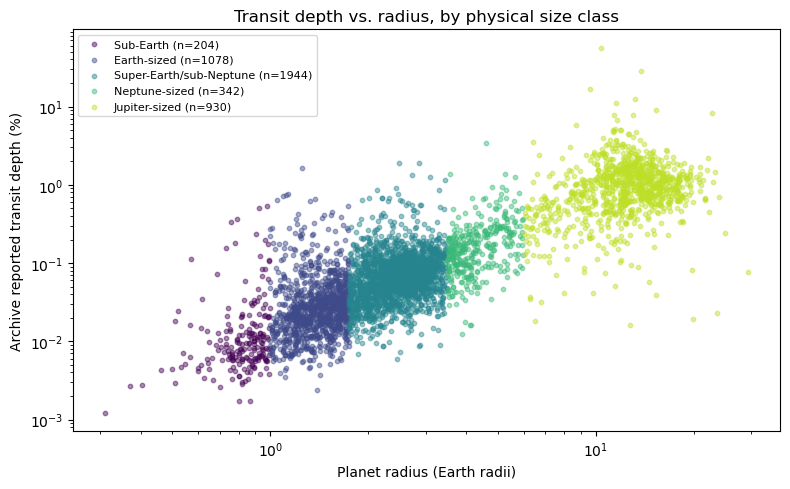

In [6]:
fig, ax = plt.subplots(figsize=(8, 5))
colors = plt.cm.viridis(np.linspace(0, 0.9, len(bins)))
for (lo, hi, label), c in zip(bins, colors):
    sel = df[(df.pl_rade >= lo) & (df.pl_rade < hi)]
    if len(sel) > 0:
        ax.scatter(sel.pl_rade, sel.depth_reported_pct, s=10, alpha=0.45, color=c,
                   label=f'{label} (n={len(sel)})')
ax.set_xscale('log'); ax.set_yscale('log')
ax.set_xlabel('Planet radius (Earth radii)')
ax.set_ylabel('Archive reported transit depth (%)')
ax.set_title('Transit depth vs. radius, by physical size class')
ax.legend(fontsize=8)
fig.tight_layout()
fig.savefig('depth_vs_radius_bins.png', dpi=150)
plt.show()

## What I'd look at next

- Restrict the comparison to planets with `st_rad` derived in the *same* discovery paper as `pl_trandep`, to remove depth/radius pairs that come from mismatched literature sources.
- Fold in limb-darkening coefficients and impact parameter (`pl_imppar`) to build a full transit-light-curve model instead of the pure-geometry approximation, which should shrink the residual scatter further.
- Compare the RV-detected vs. transit-detected sub-sample separately, since RV-confirmed transiting planets often have independently measured masses that could cross-check the radius scale.

**Citation:** This research has made use of the NASA Exoplanet Archive, which is operated by the California Institute of Technology, under contract with the National Aeronautics and Space Administration under the Exoplanet Exploration Program. See the archive's citation policy: https://exoplanetarchive.ipac.caltech.edu/docs/counts_detail.html